# 04: Random Forest Model Development (Price Prediction)


This notebook follows the same simple structure as Notebook 03 (Linear Regression), but replaces the model with **Random Forest Regressor**.

Included:
- Train/test split (chronological)
- Standard cross validation (K-Fold)
- Time series cross validation (TimeSeriesSplit)
- Exhaustive grid search for hyperparameter tuning


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from utils import (
    load_data, 
    train_test_split, 
    visualize_predictions, 
    train_test_model, 
    visualize_prediction_vs_actual, 
    time_series_grid_search
)


sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


In [7]:
df, feature_cols,target_col =  load_data()
X_train, y_train, X_test, y_test = train_test_split(df, feature_cols, target_col)

Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14', 'volume']
Train rows: 1984
Test rows:  495
Train period: 2016-06-03 -> 2024-04-22
Test period:  2024-04-23 -> 2026-04-14


In [8]:
# Primary model: Random Forest (baseline)
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=16,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)

rf_pred_train, rf_pred_test, rf_model = train_test_model(rf_model, X_train, y_train, X_test, y_test)

                           Model     MAE    RMSE    MAPE      R2
0  RandomForestRegressor (train)  0.6564  1.0498  0.0067  0.9997
                          Model      MAE     RMSE    MAPE      R2
0  RandomForestRegressor (test)  43.2025  49.7932  0.1773 -2.6392


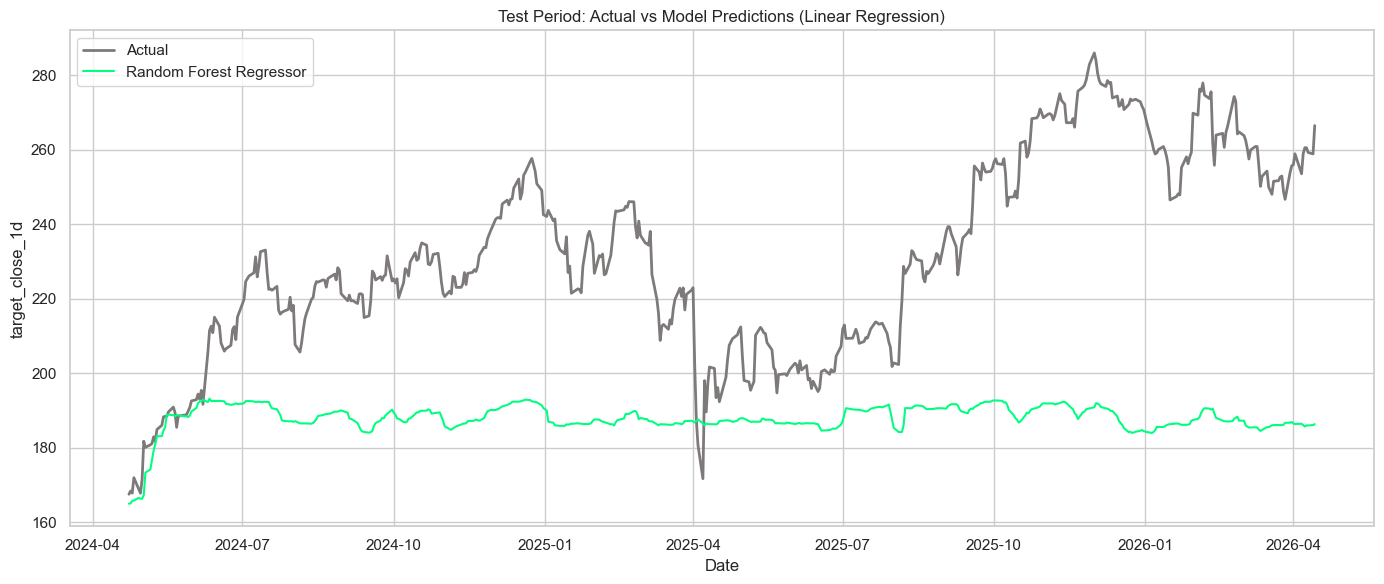

In [9]:
visualize_prediction_vs_actual(y_test, rf_pred_test, target_col, "Random Forest Regressor")

## Exhaustive Grid Search (Hyperparameter Tuning)

**Random Forest (Grid Search with TimeSeriesSplit):**  
An exhaustive `GridSearchCV` is run **only on the training set**, using `TimeSeriesSplit(n_splits=5)` to validate **forward-in-time** (train on earlier data, test on later data) and avoid leakage. The best Random Forest configuration is selected by **minimizing RMSE** (`scoring="neg_root_mean_squared_error"`).

Tuned Random Forest hyperparameters:
- `n_estimators`: number of trees (more = stabler, slower)
- `max_depth`: tree depth cap (shallower = less overfit)
- `min_samples_split`: samples to split (higher = simpler trees)
- `min_samples_leaf`: minimum leaf size (higher = smoother predictions)
- `max_features`: features per split (smaller = more randomness/regularization)
- `bootstrap`: resampling for each tree (`True` here)

Grid scale design (coarse-to-fine):
- Uses roughly multiplicative steps (e.g., 200 -> 500 -> 1000 trees).
- Covers shallow-to-deeper trees and stronger leaf/split regularization.

Outputs: `best_estimator` (tuned model) and `best_pred_test` (test-period predictions).

In [10]:
param_grid = {
    "n_estimators": [200, 500, 1000],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [1.0, "sqrt", 0.5],
    "bootstrap": [True],
}

best_estimator, best_pred_test = time_series_grid_search(
    RandomForestRegressor(), param_grid, X_train, y_train, X_test, y_test
)


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best CV root_mean_squared_error: 21.11766810869557
Best params: {'bootstrap': True, 'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
                                               Model      MAE     RMSE  \
0  RandomForestRegressor (tuned via TimeSeriesSplit)  42.9905  49.5837   

     MAPE      R2  
0  0.1764 -2.6086  


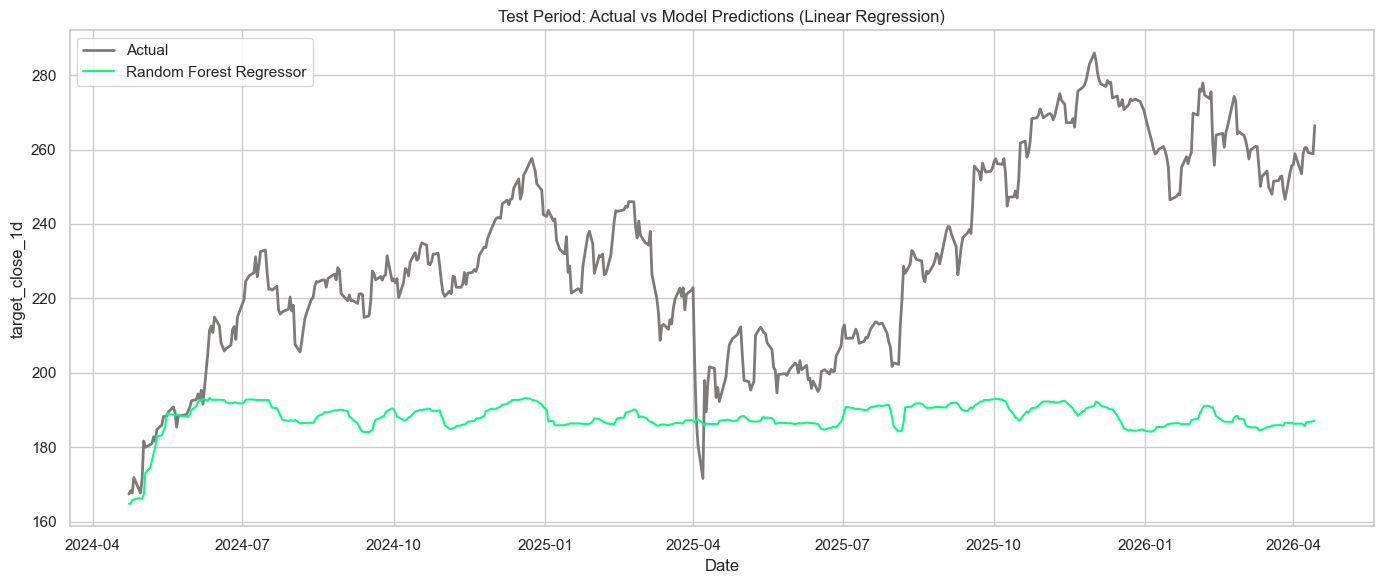

In [12]:
visualize_prediction_vs_actual(y_test, best_pred_test, target_col, "Random Forest Regressor")

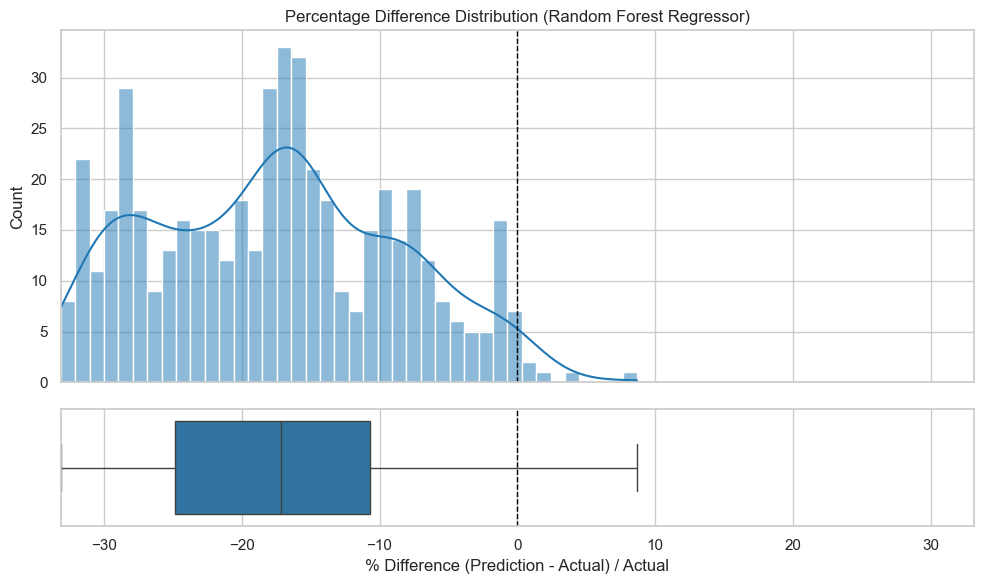

In [13]:
visualize_predictions(y_test, best_pred_test, "Random Forest Regressor")

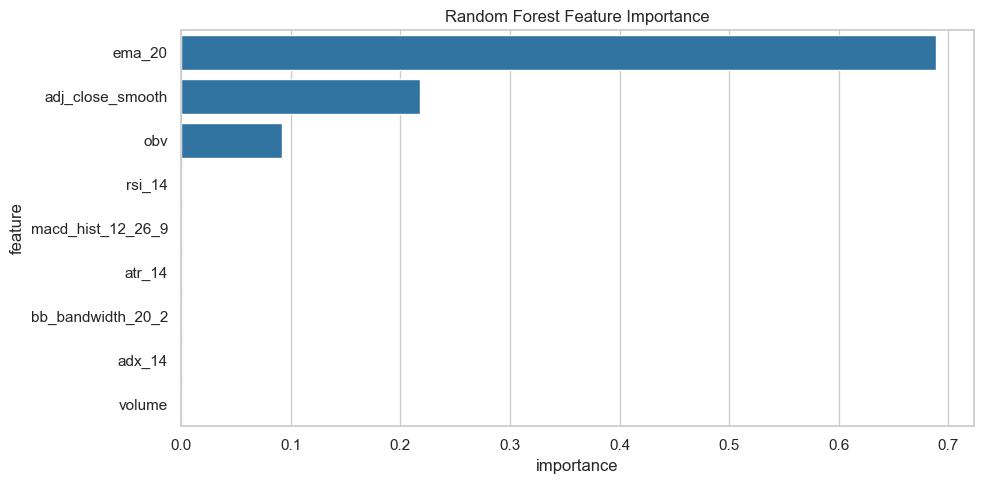

,feature,importance
6,ema_20,0.688866
5,adj_close_smooth,0.217602
4,obv,0.091990
0,rsi_14,0.000320
1,macd_hist_12_26_9,0.000289
7,atr_14,0.000260
2,bb_bandwidth_20_2,0.000235
3,adx_14,0.000232
8,volume,0.000206


In [14]:
# Feature importance via scikit API
fi = pd.DataFrame({
    "feature": feature_cols,
    "importance": best_estimator.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=fi, x="importance", y="feature", color="#1f77b4")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

fi